In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv("vehicles_dataset.csv")

In [ ]:
# =========================================================================
# AGGREGAZIONE DELLE MARCHE CON PREZZO MEDIO E ORDINAMENTO
# =========================================================================

risultato = (
    df.groupby("manufacturer")
      .agg(
          modelli_unici=("model", "nunique"),
          count_modelli=("model", "count"),
          prezzo_medio=("price", "mean")  
      )
      .reset_index()
      # Ordiniamo per il numero totale di annunci in modo decrescente (dal più diffuso al meno diffuso)
      .sort_values(by="count_modelli", ascending=False) 
)

# Arrotondiamo il prezzo medio a due cifre decimali per renderlo leggibile
risultato['prezzo_medio'] = risultato['prezzo_medio'].round(2)

print(risultato)

       manufacturer  modelli_unici  count_modelli  prezzo_medio
13             ford           3874          70269      36411.72
7         chevrolet           2611          54151     115676.10
39           toyota           1721          33944     234294.68
16            honda           1021          21155      10751.36
31           nissan            993          18948      18827.33
20             jeep            772          18873     150717.82
34              ram           1038          17367      27728.34
14              gmc           1173          16576      30405.88
4               bmw           1129          14584      26740.26
10            dodge            826          13438      15003.20
26    mercedes-benz           1201          11696     531710.56
17          hyundai            490          10278      10719.66
37           subaru            610           9457      13055.51
40       volkswagen            704           9260      12537.10
21              kia            437      

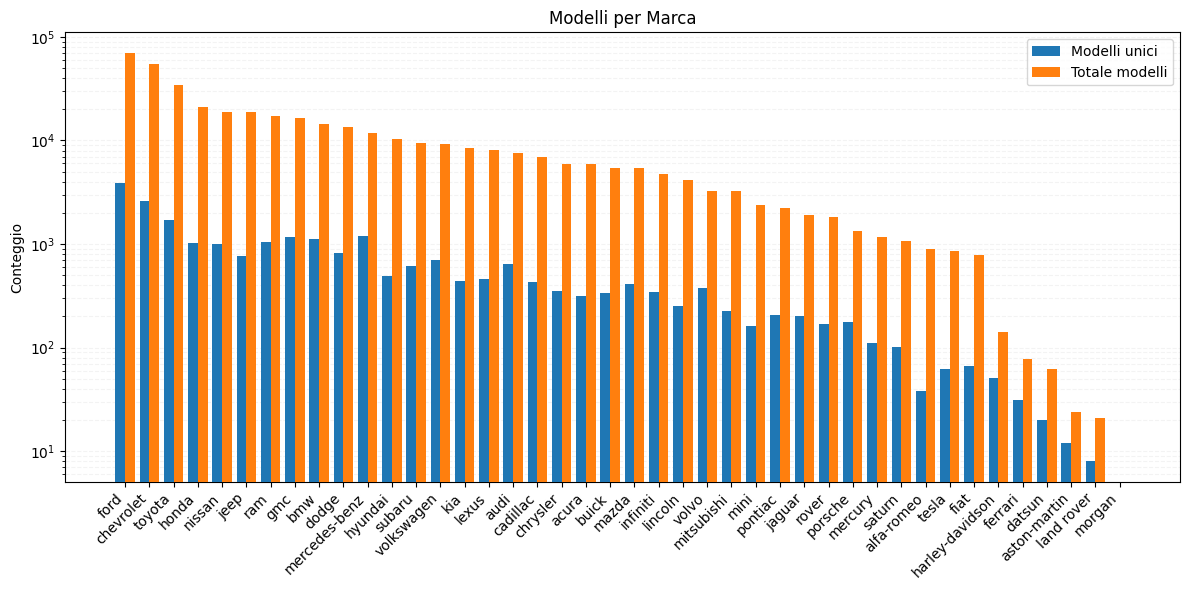

In [3]:
x = np.arange(len(risultato["manufacturer"]))
width = 0.4

plt.figure(figsize=(12, 6))

# Aggiungiamo zorder=3 per mettere le barre IN PRIMO PIANO
plt.bar(
    x - width / 2,
    risultato["modelli_unici"],
    width=width,
    color="#1f77b4",
    label="Modelli unici",
    zorder=3,
)

plt.bar(
    x + width / 2,
    risultato["count_modelli"],
    width=width,
    color="#ff7f0e",
    label="Totale modelli",
    zorder=3,
)

# Configurazione Assi e Scala Logaritmica
plt.xticks(x, risultato["manufacturer"], rotation=45, ha="right")
plt.ylabel("Conteggio")
plt.yscale("log")
plt.title("Modelli per Marca")

plt.grid(True, which="both", axis="y", linestyle="--", alpha=0.15, zorder=1)

plt.legend()
plt.tight_layout()
plt.show()

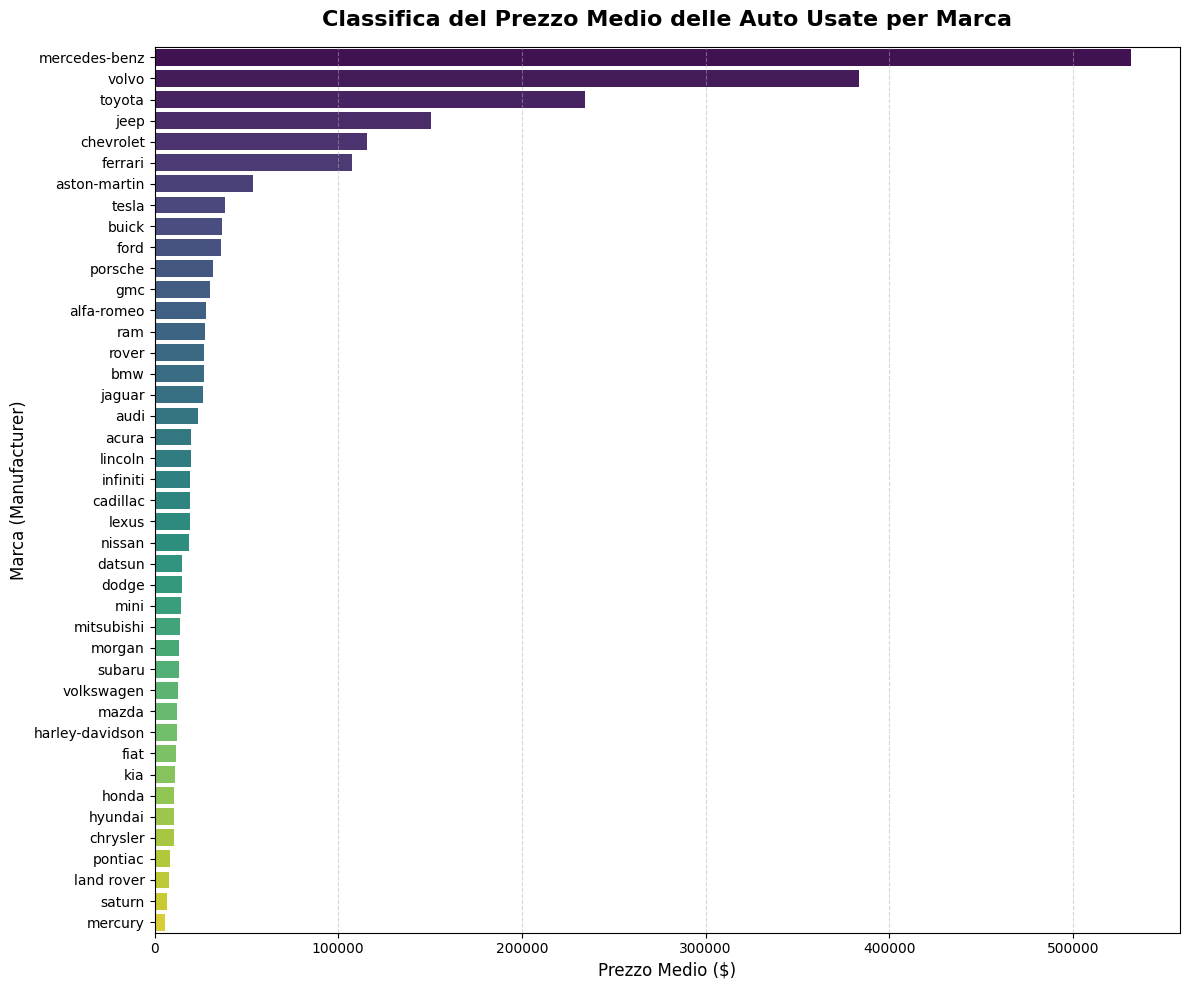

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. CALCOLO DEI PREZZI MEDI PER MARCA E ORDINAMENTO
# =========================================================================
# Raggruppiamo per marca, calcoliamo la media del prezzo e ordiniamo in modo decrescente
df_prezzi_marche = (
    df.groupby("manufacturer")["price"]
    .mean()
    .reset_index()
    .sort_values(by="price", ascending=False)
)

# =========================================================================
# 2. GENERAZIONE DEL GRAFICO A BARRE ORIZZONTALI
# =========================================================================
# Impostiamo una dimensione della figura abbastanza alta (12x10) per dare spazio a tutte le ~40 marche
plt.figure(figsize=(12, 10))

# Usiamo una palette di colori sfumata ("viridis") per renderlo elegante
sns.barplot(
    x="price", 
    y="manufacturer", 
    data=df_prezzi_marche, 
    palette="viridis",
    hue="manufacturer", # Evita i warning delle versioni recenti di Seaborn
    legend=False
)

# Personalizziamo i titoli e le etichette degli assi
plt.title("Classifica del Prezzo Medio delle Auto Usate per Marca", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Prezzo Medio ($)", fontsize=12)
plt.ylabel("Marca (Manufacturer)", fontsize=12)

# Aggiungiamo una griglia leggera verticale per aiutare a leggere i valori dei prezzi
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Ottimizziamo i margini in modo che non vengano tagliati i nomi delle marche
plt.tight_layout()

# Mostriamo il grafico a schermo
plt.show()

In [6]:
import pandas as pd

# =========================================================================
# PULIZIA OUTLIERS PER OGNI MARCA COL METODO IQR (SU TUTTO IL DATAFRAME)
# =========================================================================
# Calcoliamo i limiti di prezzo specifici per ogni brand direttamente su df,
# evitando che i prezzi folli di una marca sballino i dati delle altre.

lista_pezzi_puliti = []
tutte_le_marche = df['manufacturer'].unique()

print(f"Numero di righe totali del DataFrame PRIMA della pulizia: {df.shape[0]}")

# Cicliamo su ogni singola marca presente nel dataset
for marca in tutte_le_marche:
    
    # Isoliamo temporaneamente le auto della marca corrente
    dati_marca = df[df['manufacturer'] == marca]
    
    # Calcoliamo l'IQR solo se abbiamo un numero minimo di dati per renderlo affidabile
    if dati_marca.shape[0] > 10:
        q1 = dati_marca['price'].quantile(0.25)
        q3 = dati_marca['price'].quantile(0.75)
        iqr = q3 - q1
        
        # Definiamo i confini personalizzati per questo brand
        limite_inferiore = q1 - 1.5 * iqr
        limite_superiore = q3 + 1.5 * iqr
        
        # Di sicurezza: i prezzi non possono essere negativi o stracciati (es. 0$ o 1$)
        if limite_inferiore < 500:
            limite_inferiore = 500
    else:
        # Se la marca ha pochissimi annunci, usiamo un filtro standard di sicurezza
        limite_inferiore = 500
        limite_superiore = 100000

    # Filtriamo le auto della marca corrente che rientrano nei limiti accettabili
    auto_pulite_marca = dati_marca[(dati_marca['price'] >= limite_inferiore) & 
                                   (dati_marca['price'] <= limite_superiore)]
    
    # Salviamo il blocco pulito nella nostra lista
    lista_pezzi_puliti.append(auto_pulite_marca)

# =========================================================================
# RICOSTRUZIONE DEL DATAFRAME AGGIORNATO
# =========================================================================
# Ricompattiamo tutti i pezzi puliti in un unico DataFrame sovrascrivendo df
df = pd.concat(lista_pezzi_puliti, axis=0).reset_index(drop=True)

print("=========================================================================")
print("PULIZIA COMPLETA DEGLI OUTLIERS EFFETTUATA SU 'df'!")
print(f"-> Numero di righe totali del DataFrame DOPO la pulizia: {df.shape[0]}")
print("=========================================================================")

Numero di righe totali del DataFrame PRIMA della pulizia: 426880
PULIZIA COMPLETA DEGLI OUTLIERS EFFETTUATA SU 'df'!
-> Numero di righe totali del DataFrame DOPO la pulizia: 362358


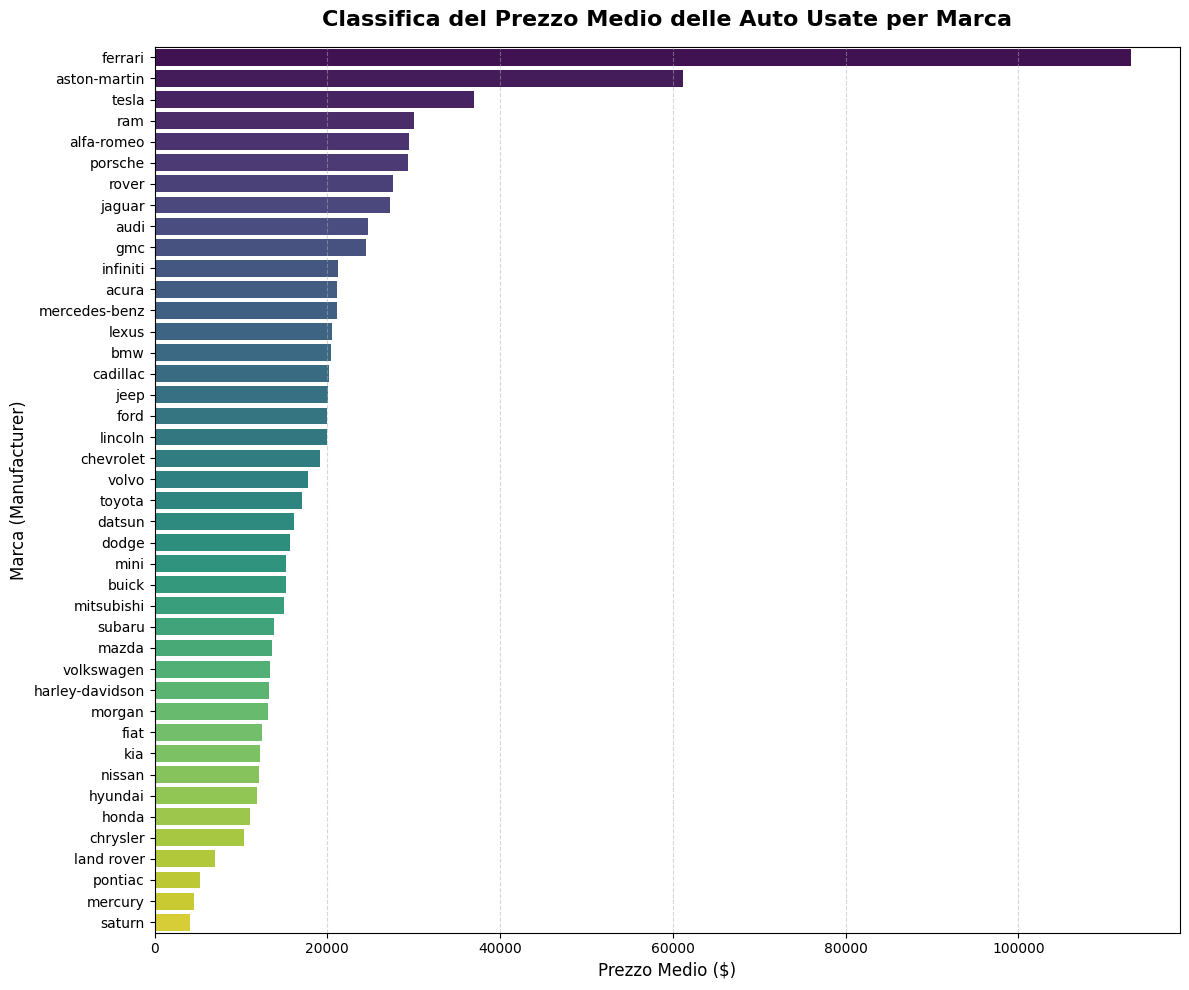

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. CALCOLO DEI PREZZI MEDI PER MARCA E ORDINAMENTO
# =========================================================================
# Raggruppiamo per marca, calcoliamo la media del prezzo e ordiniamo in modo decrescente
df_prezzi_marche = (
    df.groupby("manufacturer")["price"]
    .mean()
    .reset_index()
    .sort_values(by="price", ascending=False)
)

# =========================================================================
# 2. GENERAZIONE DEL GRAFICO A BARRE ORIZZONTALI
# =========================================================================
# Impostiamo una dimensione della figura abbastanza alta (12x10) per dare spazio a tutte le ~40 marche
plt.figure(figsize=(12, 10))

# Usiamo una palette di colori sfumata ("viridis") per renderlo elegante
sns.barplot(
    x="price", 
    y="manufacturer", 
    data=df_prezzi_marche, 
    palette="viridis",
    hue="manufacturer", # Evita i warning delle versioni recenti di Seaborn
    legend=False
)

# Personalizziamo i titoli e le etichette degli assi
plt.title("Classifica del Prezzo Medio delle Auto Usate per Marca", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Prezzo Medio ($)", fontsize=12)
plt.ylabel("Marca (Manufacturer)", fontsize=12)

# Aggiungiamo una griglia leggera verticale per aiutare a leggere i valori dei prezzi
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Ottimizziamo i margini in modo che non vengano tagliati i nomi delle marche
plt.tight_layout()

# Mostriamo il grafico a schermo
plt.show()
# =========================================================================

In [8]:
# =========================================================================
# RIMOZIONE COMPLETA DEI BRAND DI SUPERCAR (FERRARI E ASTON MARTIN)
# =========================================================================
# Eliminiamo del tutto le righe di queste due marche dal DataFrame originale df.

print(f"Numero di auto prima della rimozione: {df.shape[0]}")

# Definiamo la lista delle marche da eliminare (scritte in minuscolo come nel dataset)
marche_da_escludere = ['ferrari', 'aston-martin']

# Filtriamo il DataFrame tenendo solo i brand NON presenti nella lista
# il tilde prende tutto tranne quelle citate
df = df[~df['manufacturer'].isin(marche_da_escludere)].reset_index(drop=True)

print("=========================================================================")
print("RIMOZIONE SUPERCAR COMPLETATA!")
print(f"-> Numero di auto rimaste nel DataFrame 'df': {df.shape[0]}")
print("=========================================================================")

Numero di auto prima della rimozione: 362358
RIMOZIONE SUPERCAR COMPLETATA!
-> Numero di auto rimaste nel DataFrame 'df': 362262


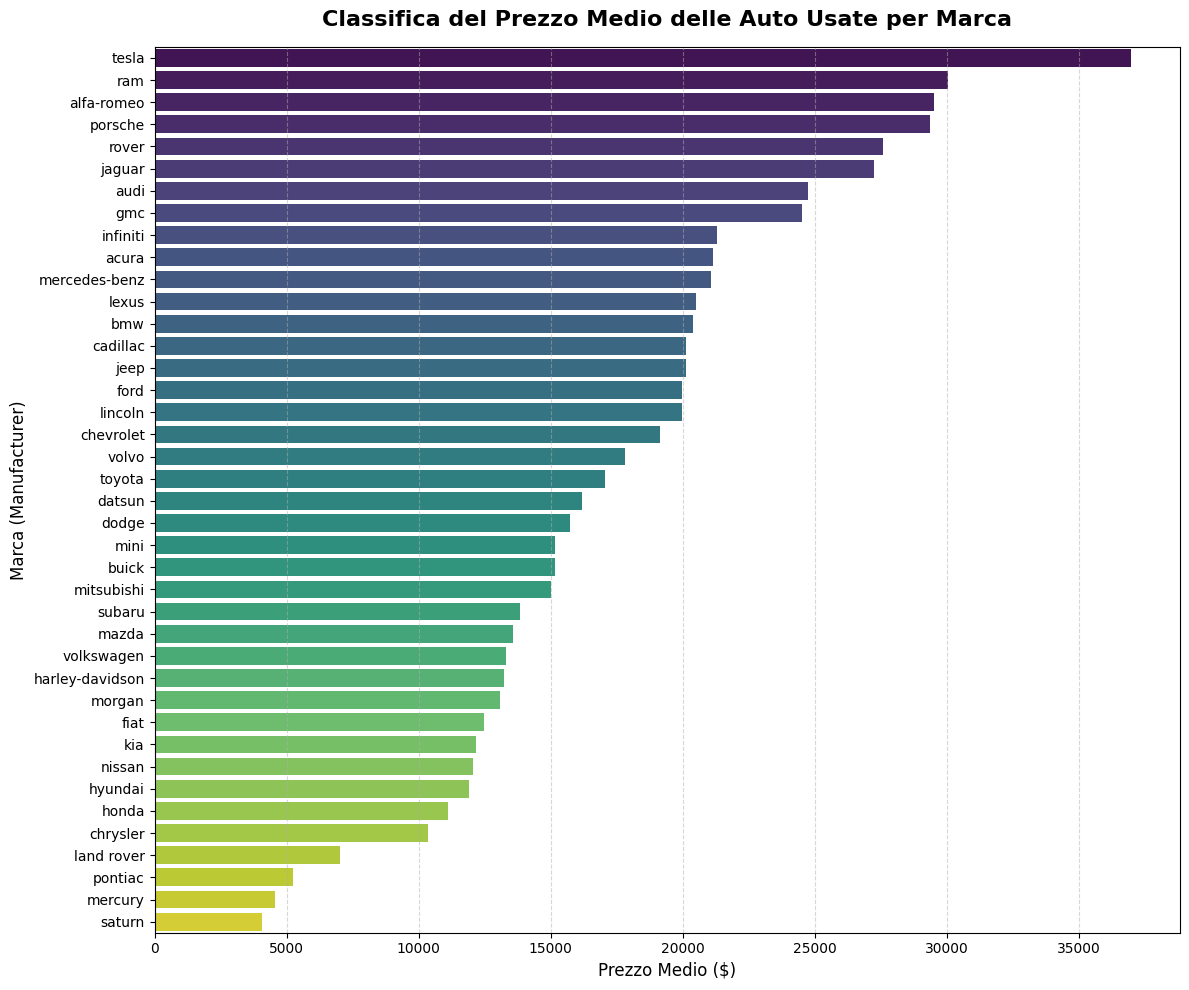

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. CALCOLO DEI PREZZI MEDI PER MARCA E ORDINAMENTO
# =========================================================================
# Raggruppiamo per marca, calcoliamo la media del prezzo e ordiniamo in modo decrescente
df_prezzi_marche = (
    df.groupby("manufacturer")["price"]
    .mean()
    .reset_index()
    .sort_values(by="price", ascending=False)
)

# =========================================================================
# 2. GENERAZIONE DEL GRAFICO A BARRE ORIZZONTALI
# =========================================================================
# Impostiamo una dimensione della figura abbastanza alta (12x10) per dare spazio a tutte le ~40 marche
plt.figure(figsize=(12, 10))

# Usiamo una palette di colori sfumata ("viridis") per renderlo elegante
sns.barplot(
    x="price", 
    y="manufacturer", 
    data=df_prezzi_marche, 
    palette="viridis",
    hue="manufacturer", # Evita i warning delle versioni recenti di Seaborn
    legend=False
)

# Personalizziamo i titoli e le etichette degli assi
plt.title("Classifica del Prezzo Medio delle Auto Usate per Marca", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Prezzo Medio ($)", fontsize=12)
plt.ylabel("Marca (Manufacturer)", fontsize=12)

# Aggiungiamo una griglia leggera verticale per aiutare a leggere i valori dei prezzi
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Ottimizziamo i margini in modo che non vengano tagliati i nomi delle marche
plt.tight_layout()

# Mostriamo il grafico a schermo
plt.show()
# =========================================================================

In [10]:

print(f"Numero di auto prima della rimozione: {df.shape[0]}")

# Definiamo la lista delle marche da eliminare (scritte in minuscolo come nel dataset)
marche_da_escludere = ['saturn', 'mercury', 'pontiac', 'land rover']

# Filtriamo il DataFrame tenendo solo i brand NON presenti nella lista
df = df[~df['manufacturer'].isin(marche_da_escludere)].reset_index(drop=True)

print("=========================================================================")
print("RIMOZIONE AUTO ECONOMICHE COMPLETATA!")
print(f"-> Numero di auto rimaste nel DataFrame 'df': {df.shape[0]}")
print("=========================================================================")

Numero di auto prima della rimozione: 362262
RIMOZIONE AUTO ECONOMICHE COMPLETATA!
-> Numero di auto rimaste nel DataFrame 'df': 358385


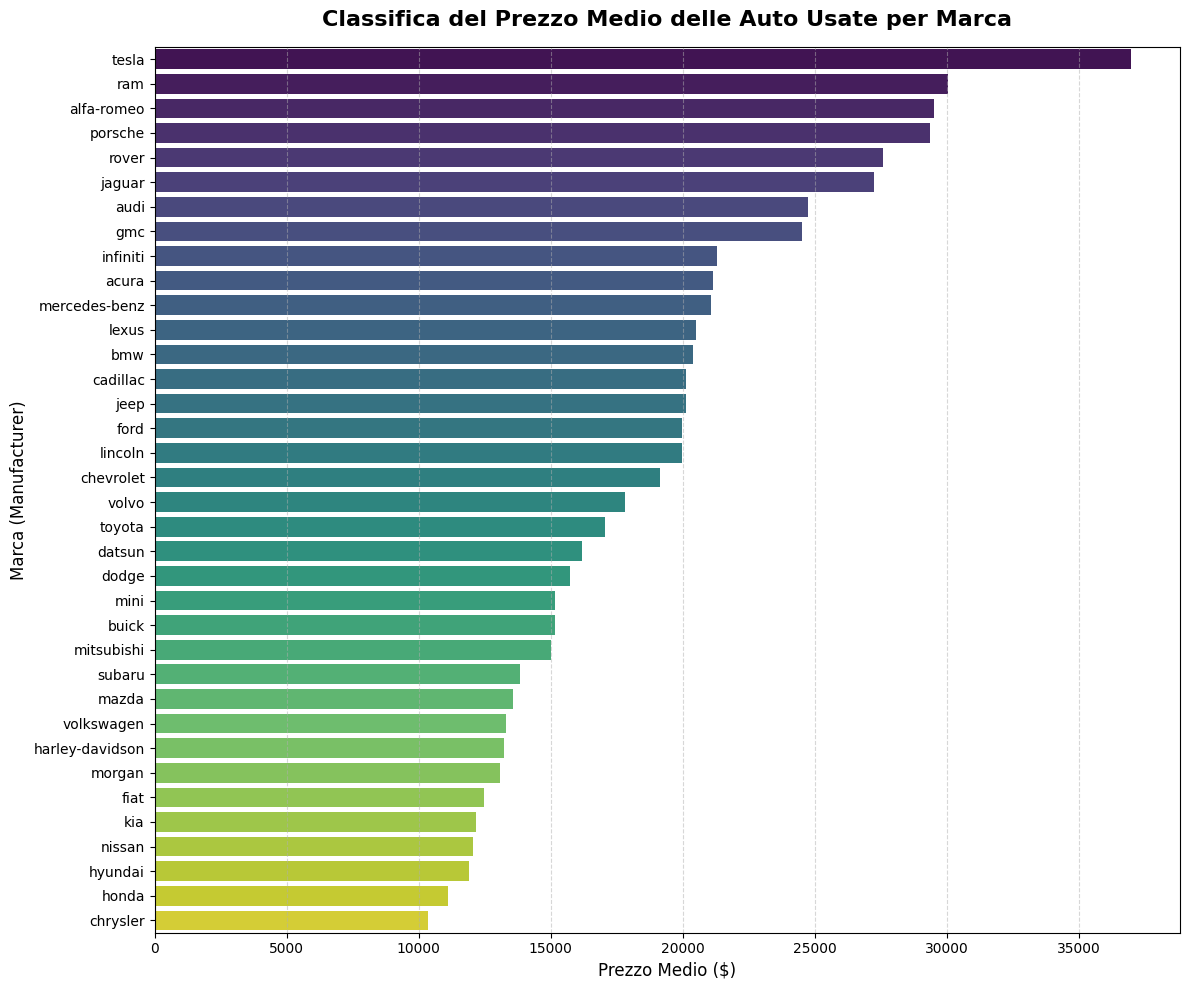

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 1. CALCOLO DEI PREZZI MEDI PER MARCA E ORDINAMENTO
# =========================================================================
# Raggruppiamo per marca, calcoliamo la media del prezzo e ordiniamo in modo decrescente
df_prezzi_marche = (
    df.groupby("manufacturer")["price"]
    .mean()
    .reset_index()
    .sort_values(by="price", ascending=False)
)

# =========================================================================
# 2. GENERAZIONE DEL GRAFICO A BARRE ORIZZONTALI
# =========================================================================
# Impostiamo una dimensione della figura abbastanza alta (12x10) per dare spazio a tutte le ~40 marche
plt.figure(figsize=(12, 10))

# Usiamo una palette di colori sfumata ("viridis") per renderlo elegante
sns.barplot(
    x="price", 
    y="manufacturer", 
    data=df_prezzi_marche, 
    palette="viridis",
    hue="manufacturer", # Evita i warning delle versioni recenti di Seaborn
    legend=False
)

# Personalizziamo i titoli e le etichette degli assi
plt.title("Classifica del Prezzo Medio delle Auto Usate per Marca", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Prezzo Medio ($)", fontsize=12)
plt.ylabel("Marca (Manufacturer)", fontsize=12)

# Aggiungiamo una griglia leggera verticale per aiutare a leggere i valori dei prezzi
plt.grid(axis='x', linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price'])
y = df['price']

X_wo_train, X_wo_test, y_wo_train, y_wo_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=X["manufacturer"])

# --- 1. RIMOZIONE VALORI NULLI ---
colonne_da_droppare = ['fuel', 'year', 'model', 'transmission', 'title_status', 'odometer', 'manufacturer']

X_wo_train = X_wo_train.dropna(subset=colonne_da_droppare)
y_wo_train = y_wo_train.loc[X_wo_train.index] # Allineiamo le etichette (y) agli indici rimasti in X

X_wo_test = X_wo_test.dropna(subset=colonne_da_droppare)
y_wo_test = y_wo_test.loc[X_wo_test.index]

# --- 2. RIEMPIMENTO VALORI NULLI CON 'Unknown' (Corretto) ---
# Attenzione: lo facciamo su X_train e X_test, non su df!
colonne_da_riempire = ['condition', 'cylinders', 'drive', 'size', 'type', 'paint_color']

X_wo_train[colonne_da_riempire] = X_wo_train[colonne_da_riempire].fillna('Unknown')
X_wo_test[colonne_da_riempire] = X_wo_test[colonne_da_riempire].fillna('Unknown')

print(f"Dimensioni finali X_wo_train: {X_wo_train.shape}")
print(f"Dimensioni finali X_wo_test: {X_wo_test.shape}")

# --- 3. SALVATAGGIO IN CSV ---
print("Salvataggio dei file CSV in corso...")

# index=False evita di salvare la numerazione delle righe come colonna aggiuntiva nel CSV
X_wo_train.to_csv('X_wo_train.csv', index=False)
X_wo_test.to_csv('X_wo_test.csv', index=False)

# y_train e y_test sono Series, ma il metodo to_csv funziona allo stesso modo
y_wo_train.to_csv('y_wo_train.csv', index=False)
y_wo_test.to_csv('y_wo_test.csv', index=False)

print("Tutti e 4 i dataset sono stati salvati con successo!")

Dimensioni finali X_wo_train: (274755, 14)
Dimensioni finali X_wo_test: (68640, 14)
Salvataggio dei file CSV in corso...
Tutti e 4 i dataset sono stati salvati con successo!


In [13]:
X_wo_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 274755 entries, 125303 to 311050
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          274755 non-null  float64
 1   manufacturer  274755 non-null  object 
 2   model         274755 non-null  object 
 3   condition     274755 non-null  object 
 4   cylinders     274755 non-null  object 
 5   fuel          274755 non-null  object 
 6   odometer      274755 non-null  float64
 7   title_status  274755 non-null  object 
 8   transmission  274755 non-null  object 
 9   drive         274755 non-null  object 
 10  size          274755 non-null  object 
 11  type          274755 non-null  object 
 12  paint_color   274755 non-null  object 
 13  state         274755 non-null  object 
dtypes: float64(2), object(12)
memory usage: 31.4+ MB
